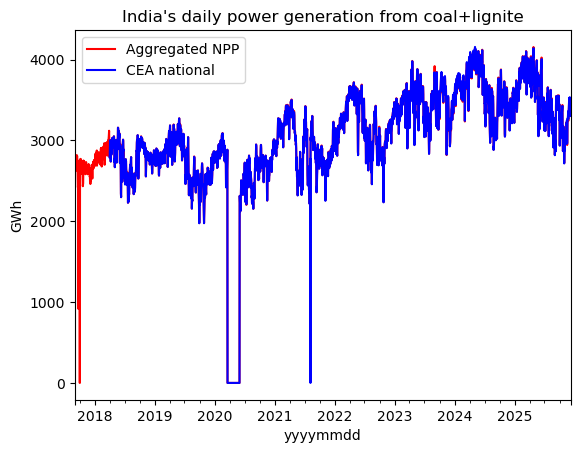

In [22]:
########################################################################################
#
# ANALYSE THE DATA TIME SERIES, MATCH WITH GIPT, AND SENSE CHECK AGAINST DAILY AGGREGATE GENERATION PER SOURCE
#
########################################################################################

import pandas as pd 
from pylab import *

#LOAD DGR DATA
dgr2_all=pd.read_parquet('./npp_daily_generation.parquet')

# SENSE CHECK AGAINST CEA AGGREGATED DATA
all_india=pd.read_csv("./CEA_DGR_data_11.12.25.csv")
all_india.index=pd.to_datetime(all_india['yyyymmdd'],format='%Y%m%d')

#MAPPINGS OF DAILY GENERATION REPORTS TO GIPT
crosswalk=pd.read_csv('./NPP_GIPT_crosswalk.csv')
crosswalk['concat']=crosswalk['DGR plant name']+crosswalk['DGR unit']

#MERGE USING NAME AND UNIT FOR COAL AND NUCLEAR (WITH UNITS) AND WITH NAME FOR HYDRO AND GAS/OIL (WITHOUT UNITS)
dgr2_all_with_units=pd.merge(dgr2_all[['name', 'unit', 'capacity', 'day gen','datetime', 'concat']],crosswalk[crosswalk.concat.notnull()],left_on='concat',right_on='concat')
dgr2_all_without_units=pd.merge(dgr2_all[['name', 'unit', 'capacity', 'day gen','datetime']],crosswalk[crosswalk.concat.isnull()].drop_duplicates(subset=['DGR plant name'], keep='first'),left_on='name',right_on='DGR plant name',how='left')
dgr2_all_with_units.index=pd.to_datetime(dgr2_all_with_units['datetime'],format='%Y-%m-%d')
dgr2_all_without_units.index=pd.to_datetime(dgr2_all_without_units['datetime'],format='%Y-%m-%d')

#PLOT TIMESERIES COAL AND LIGNITE
dgr2_all_with_units[(dgr2_all_with_units['Type']=='coal')]['day gen'].resample('d').sum().plot(c='r')
all_india[['CEA.DGR.COL','CEA.DGR.LIG']].resample('d').sum().sum(axis=1).plot(c='b')
plt.title("India's daily power generation from coal+lignite")
plt.ylabel('GWh')
plt.legend(['Aggregated NPP', 'CEA national'])


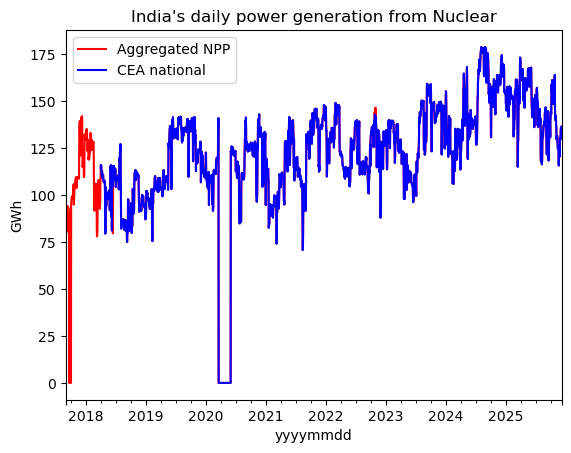

In [20]:
#PLOT TIMESERIES NCULEAR
dgr2_all_with_units[(dgr2_all_with_units['Type']=='nuclear')]['day gen'].resample('d').sum().plot(c='r')
all_india[['CEA.DGR.NUC']].resample('d').sum().sum(axis=1).plot(c='b')
plt.title("India's daily power generation from Nuclear")
plt.ylabel('GWh')
plt.legend(['Aggregated NPP', 'CEA national'])


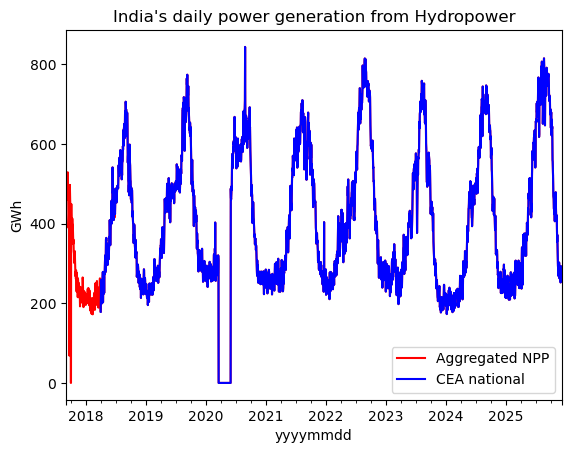

In [23]:
#PLOT TIMESERIES HYDRO
dgr2_all_without_units[dgr2_all_without_units['Type']=='hydropower']['day gen'].resample('d').sum().plot(c='r')
all_india[['CEA.DGR.HYD']].resample('d').sum().sum(axis=1).plot(c='b')
plt.title("India's daily power generation from Hydropower")
plt.ylabel('GWh')
plt.legend(['Aggregated NPP', 'CEA national'])
